In [15]:
from __future__ import annotations
import random
import numpy as np
from minigrid.core.grid import Grid
from minigrid.core.mission import MissionSpace
from minigrid.core.world_object import Goal, Key, Door, Wall
from minigrid.minigrid_env import MiniGridEnv
from config import CURRICULUM_REWARDS, CURRICULUM_STEPS
from envs.wrappers import ConvWrapper

def _gen_mission():
        return "navigate clutter"

class Room:
    
    def draw_room(x_low,
                 x_high,
                 y_low,
                 y_high,
                 grid
                 ):
        pass

        
    
class EmptyRoom(Room):
    def draw_room(x_low,
                 x_high,
                 y_low,
                 y_high,
                 grid
                 ):
        grid.wall_rect(x_low, y_low, x_high - x_low, y_high-y_low)
        
class Node:
    def __init__(self,
                 x_low,
                 x_high,
                 y_low,
                 y_high,
                 split_idx=None,
                 split_axis=None,
                 left=None,
                 right=None,
                 room: Room=None
                ):
        self.x_low = x_low
        self.split_axis = split_axis
        self.x_high = x_high
        self.y_low = y_low
        self.split_idx = split_idx
        self.y_high = y_high
        self.left = left
        self.right = right
        self.room = room
    

    def get_width(self):
        return self.x_high - self.x_low - 2

    def get_height(self):
        return self.y_high - self.y_low - 2

    def get_center_cords(self):
        return (self.x_high - self.x_low) // 2, (self.y_high - self.y_low) // 2
    
    
    def draw_room(self, grid):
        self.room.draw_room(x_high=self.x_high, x_low=self.x_low, y_low=self.y_low, y_high=self.y_high, grid=grid)

        
class BSP(MiniGridEnv):
    def __init__(
            self,
            min_room_size=5,  
            max_room_size=10,   
            size=12,
            big_room_chance=0,
            render_mode="rgb_array",
            **kwargs,
    ):
        mission_space = MissionSpace(mission_func=_gen_mission)
        self.min_room_size=min_room_size 
        self.size = size
        self.max_room_size=max_room_size
        self.big_room_chance=big_room_chance
        self.tree = None
        self.leafs = []

        super().__init__(
            mission_space=mission_space,
            render_mode=render_mode,
            width=size,
            height=size,
            see_through_walls=False,
            **kwargs,
        )
    
    def _split(self, root: Node):

        choose_x = random.choice([True, False])

    
        can_split_x = root.get_width() > 2 * self.min_room_size
        can_split_y = root.get_height() > 2 * self.min_room_size
        if not can_split_x and not can_split_y:
                self.leafs.append(root)
     
        should_split_x =  not can_split_y and root.get_width() > self.max_room_size
        should_split_y =  not can_split_x and root.get_height() > self.max_room_size

        if can_split_x and (choose_x or should_split_x):
           
            split_idx = random.randint(root.x_low + self.min_room_size+1, root.x_high - self.min_room_size-2)
            root.split_idx
            root.left = Node(
                x_low=root.x_low,
                x_high=split_idx+1,
                y_low=root.y_low,
                y_high=root.y_high,
                room=EmptyRoom
            )
            root.right = Node(
                x_low=split_idx,
                x_high=root.x_high,
                y_low=root.y_low,
                y_high=root.y_high,
                room=EmptyRoom
            ) 
            self._split(root.left)
            self._split(root.right)
            
      
        elif can_split_y and (not choose_x or should_split_y):
           
            split_idx = random.randint(root.y_low+1+ self.min_room_size, root.y_high - self.min_room_size-2)
            root.left = Node(
                x_low=root.x_low,
                x_high=root.x_high,
                y_low=root.y_low,
                y_high=split_idx+1,
                room=EmptyRoom
            )
            root.right = Node(
                x_low=root.x_low,
                x_high=root.x_high,
                y_low=split_idx,
                y_high=root.y_high,
                room=EmptyRoom
            )
            self._split(root.left)
            self._split(root.right)
        
   
    def print_leafs(self, node: Node):
        if not node:
            return
        if not node.left and not node.right:
            print(f"x_low: {node.x_low}, x_high: {node.x_high}, y_low: {node.y_low}, y_high: {node.y_high}, width: {node.get_width()}, height: {node.get_height()}")
                
        self.print_leafs(node.left)
        self.print_leafs(node.right)

    def partition_rooms(self):
        x_low, x_high, y_low, y_high = 0, self.size, 0, self.size
        
        self.tree = Node(x_low=x_low, x_high=x_high, y_low=y_low, y_high=y_high, room=EmptyRoom)
        self._split(self.tree)
    
    def draw_traversal(self, node:Node):
        if not node.left and not node.right:
            node.draw_room(self.grid)
        
        if node.left:
            self.draw_traversal(node.left)
        if node.right:
            self.draw_traversal(node.right)
    

        

    def connect_rooms(self, node: Node):
        if not node:
            return
        
        # 1. Erst die Kinder verbinden (Bottom-Up)
        if node.left:
            self.connect_rooms(node.left)
        if node.right:
            self.connect_rooms(node.right)
            
        # 2. Wenn es ein Leaf ist (keine Kinder), gibts nichts zu verbinden
        if not node.left and not node.right:
            return

        # 3. Verbinde das linke und rechte Kind DIESES Nodes
        if node.split_axis == 'x':
            # Die Trennwand ist vertikal bei x = split_idx.
            # Wir suchen uns eine zufällige y-Koordinate auf dieser Wand.
            # (+1 und -2 verhindert, dass wir Türen genau in die Ecken bauen)
            door_x = node.split_idx
            door_y = random.randint(node.y_low + 1, node.y_high - 2)
            
            # Wand einreißen (None) oder eine Tür einbauen:
            self.grid.set(door_x, door_y, None) 
            # Alternativ: self.grid.set(door_x, door_y, Door('green', is_locked=False))

        elif node.split_axis == 'y':
            # Die Trennwand ist horizontal bei y = split_idx.
            door_y = node.split_idx
            door_x = random.randint(node.x_low + 1, node.x_high - 2)
            
            self.grid.set(door_x, door_y, None)

    def draw_rooms(self):
        self.grid = Grid(self.size, self.size)
       
        self.grid.wall_rect(0, 0, self.grid.width, self.grid.height)
        self.draw_traversal(self.tree)
        self.place_agent()
        

In [16]:
env = BSP(
    min_room_size=4,
    max_room_size=5,
    size=30
)

In [17]:
env.partition_rooms()

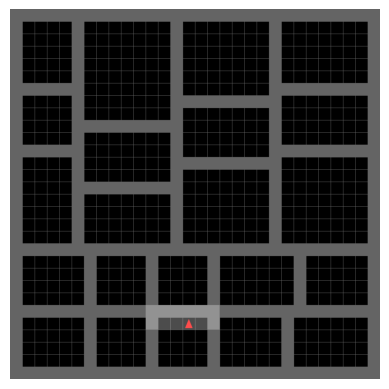

In [18]:
import matplotlib.pyplot as plt
env.draw_rooms()
frame = env.render()

plt.imshow(frame)
plt.axis('off') 
plt.show()

In [19]:
from minigrid.core.roomgrid import RoomGrid, Room
from minigrid.core.mission import MissionSpace

class RoomEnv(RoomGrid):
    def __init__(self, size, render_mode="rgb_array", **kwargs):
        # 1. RoomGrid braucht zwingend Infos zu Raumgröße und Anzahl der Räume
        super().__init__(
            mission_space=MissionSpace(mission_func=lambda: "Mission"),
            room_size=size,
            render_mode=render_mode,
            **kwargs
        )

    # 2. Setup (wie Agenten platzieren) gehört immer in _gen_grid
    def _gen_grid(self, width, height):
        Room((0,0),(self.room_size, self.room_size))
        self.place_agent()

In [20]:
env = RoomEnv(8)

In [21]:
import matplotlib.pyplot as plt
env.reset()
frame = env.render()

plt.imshow(frame)
plt.axis('off') 
plt.show()

AttributeError: 'RoomEnv' object has no attribute 'room_grid'